Project Title : Social Media Content Engagement Prediction - Project Guide


Problem Statement
Brands, influencers, and digital marketing teams constantly try to understand which type of content is likely to generate
stronger audience response. Engagement typically includes likes, comments, shares, saves, clicks, and other
meaningful interactions that indicate how users respond to a post. Predicting engagement in advance helps marketers
improve content planning, posting strategy, audience targeting, and campaign effectiveness.
In this project, the objective is to predict the engagement_score of a social media post using post-level, timing-level,
audience-level, and campaign-level variables. Since the target is a continuous numeric value, this problem is treated
as a regression task

Data Dictionary


Data Dictionary
Column Description
post_type Type of post such as image, carousel, reel, or video
caption_length Total number of characters in the caption
hashtags_count Number of hashtags used in the post
mentions_count Number of tagged accounts or mentions
emoji_count Number of emojis used in the caption
has_call_to_action Whether the caption contains a call-to-action
uses_trending_audio Whether the post uses trending audio
content_topic Main topic category of the content
hour_posted Hour at which the content was posted
day_of_week Day of the week when the post was published
is_weekend Indicates whether the post was published on a weekend
followers_count Total followers of the account
audience_active_percent Estimated percentage of followers active at posting time
avg_past_engagement Average engagement score of past posts
account_age_days Age of the account in days
impressions Total number of times the post was shown
reach Number of unique users reached
profile_visits Number of profile visits generated by the post
watch_time_seconds Total watch time in seconds for video-based content
completion_rate Percentage of viewers who watched the content fully
click_through_rate Percentage of users who clicked the link or CTA
is_paid_promotion Whether the post received paid promotion support
ad_spend Amount spent on promoting the content
collaboration_flag Whether the post is a collaboration post
Column
engagement_score
Description
Target variable representing overall post engagement

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
df=pd.read_csv("Downloads/social_media_engagement_prediction_dataset.csv")

In [5]:
df.head()

,platform,content_type,content_topic,creator_category,post_hour,day_of_week,is_weekend,is_peak_time,caption_length,hashtag_count,...,sentiment_score_caption,followers_count,audience_active_percent,avg_past_engagement,posting_frequency_per_week,account_age_days,is_paid_promotion,ad_spend_usd,collaboration_flag,engagement_score
0,Facebook,Text,Entertainment,Business,5,4,0,0,76,8,...,-0.063,9441,31.03,702.31,5.9,938,0,0.00,0,797.05
1,Instagram,Reel,News,Personal Brand,4,1,0,0,315,7,...,0.184,7137,61.37,748.11,1.4,636,1,89.38,0,953.34
2,Instagram,Reel,Education,Educator,2,5,1,0,87,9,...,-0.036,6831,65.03,32.06,3.2,1247,0,0.00,0,1011.13
3,Instagram,Reel,Motivation,Media,17,0,0,0,265,4,...,0.112,4710,60.02,755.05,1.2,1211,0,0.00,0,925.88
4,Instagram,Video,Motivation,Personal Brand,4,2,0,0,201,3,...,0.505,54499,16.00,820.17,2.0,139,0,0.00,0,787.08


In [4]:
df.tail()

,platform,content_type,content_topic,creator_category,post_hour,day_of_week,is_weekend,is_peak_time,caption_length,hashtag_count,...,sentiment_score_caption,followers_count,audience_active_percent,avg_past_engagement,posting_frequency_per_week,account_age_days,is_paid_promotion,ad_spend_usd,collaboration_flag,engagement_score
9995,LinkedIn,Carousel,Education,Educator,2,4,0,0,60,13,...,0.626,29560,43.51,608.23,7.9,575,0,0.00,0,1042.54
9996,YouTube Shorts,Reel,Motivation,Educator,13,4,0,1,165,12,...,-0.111,39768,44.24,903.45,4.3,1118,1,105.00,1,1135.03
9997,YouTube Shorts,Video,Lifestyle,Educator,11,6,1,1,63,8,...,-0.048,47936,42.47,790.62,4.2,883,1,159.97,0,949.39
9998,LinkedIn,Text,Education,Influencer,18,0,0,1,98,7,...,0.449,37616,46.73,564.04,7.0,139,0,0.00,0,1038.63
9999,LinkedIn,Text,Lifestyle,Educator,15,0,0,0,198,6,...,0.206,11803,36.35,2224.23,3.4,801,0,0.00,0,1115.95


In [5]:
df.isnull()

,platform,content_type,content_topic,creator_category,post_hour,day_of_week,is_weekend,is_peak_time,caption_length,hashtag_count,...,sentiment_score_caption,followers_count,audience_active_percent,avg_past_engagement,posting_frequency_per_week,account_age_days,is_paid_promotion,ad_spend_usd,collaboration_flag,engagement_score
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [7]:
df.isnull().sum()

platform                      0
content_type                  0
content_topic                 0
creator_category              0
post_hour                     0
day_of_week                   0
is_weekend                    0
is_peak_time                  0
caption_length                0
hashtag_count                 0
mention_count                 0
emoji_count                   0
has_call_to_action            0
uses_trending_audio           0
carousel_slides               0
video_duration_sec            0
media_quality_score           0
sentiment_score_caption       0
followers_count               0
audience_active_percent       0
avg_past_engagement           0
posting_frequency_per_week    0
account_age_days              0
is_paid_promotion             0
ad_spend_usd                  0
collaboration_flag            0
engagement_score              0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   platform                    10000 non-null  object 
 1   content_type                10000 non-null  object 
 2   content_topic               10000 non-null  object 
 3   creator_category            10000 non-null  object 
 4   post_hour                   10000 non-null  int64  
 5   day_of_week                 10000 non-null  int64  
 6   is_weekend                  10000 non-null  int64  
 7   is_peak_time                10000 non-null  int64  
 8   caption_length              10000 non-null  int64  
 9   hashtag_count               10000 non-null  int64  
 10  mention_count               10000 non-null  int64  
 11  emoji_count                 10000 non-null  int64  
 12  has_call_to_action          10000 non-null  int64  
 13  uses_trending_audio         1000

In [9]:
df.describe()

,post_hour,day_of_week,is_weekend,is_peak_time,caption_length,hashtag_count,mention_count,emoji_count,has_call_to_action,uses_trending_audio,...,sentiment_score_caption,followers_count,audience_active_percent,avg_past_engagement,posting_frequency_per_week,account_age_days,is_paid_promotion,ad_spend_usd,collaboration_flag,engagement_score
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,11.573100,2.983200,0.282900,0.339800,140.808500,7.029200,1.217700,3.023400,0.457300,0.162500,...,0.140095,3.712523e+04,48.212065,867.760119,4.850620,852.542900,0.240800,69.462306,0.168100,996.671475
std,6.896406,2.001379,0.450431,0.473665,67.123003,2.712173,1.102011,1.752529,0.498198,0.368927,...,0.438538,5.067756e+04,13.907942,492.615875,2.015644,414.907001,0.427591,221.278331,0.373974,107.029183
min,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.000000,7.350000e+02,8.000000,30.000000,1.000000,30.000000,0.000000,0.000000,0.000000,525.470000
25%,6.000000,1.000000,0.000000,0.000000,93.000000,5.000000,0.000000,2.000000,0.000000,0.000000,...,-0.165000,1.079450e+04,38.650000,509.225000,3.400000,562.000000,0.000000,0.000000,0.000000,923.180000
50%,12.000000,3.000000,0.000000,0.000000,140.000000,7.000000,1.000000,3.000000,0.000000,0.000000,...,0.144000,2.221400e+04,48.370000,851.490000,4.800000,850.000000,0.000000,0.000000,0.000000,994.055000
75%,18.000000,5.000000,1.000000,1.000000,186.000000,9.000000,2.000000,4.000000,1.000000,0.000000,...,0.448000,4.420475e+04,57.600000,1205.830000,6.200000,1136.000000,0.000000,0.000000,0.000000,1066.642500
max,23.000000,6.000000,1.000000,1.000000,429.000000,21.000000,8.000000,12.000000,1.000000,1.000000,...,1.000000,1.728174e+06,96.000000,2810.410000,12.300000,2556.000000,1.000000,5193.630000,1.000000,1447.810000


EDA Questions


A. Understanding the Target Variable
1. What is the distribution of engagement_score?
2. Is the engagement_score normally distributed, skewed, or multimodal?
3. What are the minimum, maximum, mean, and median values of engagement_score?
4. Are there extreme outliers in engagement_score?
5. What percentage of posts have very low engagement compared to the rest?
6. What percentage of posts achieve exceptionally high engagement?
7. Does engagement_score vary widely across the dataset or remain concentrated in a narrow band?
8. Should the target variable be transformed because of skewness or extreme spread?
9. How stable is engagement_score across different post categories?
10. Are there unusual patterns in engagement_score that may need further investigation?

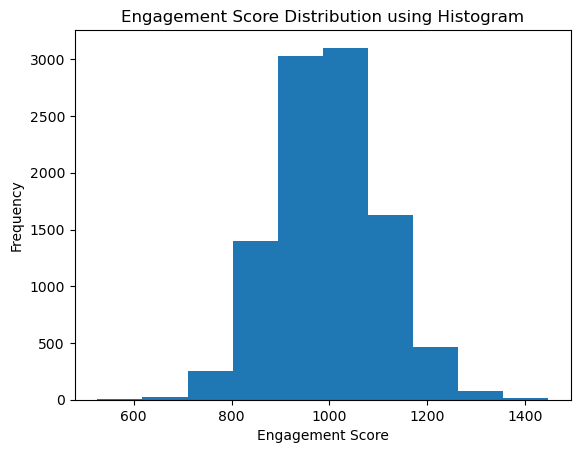

In [10]:
plt.hist(df["engagement_score"])
plt.title("Engagement Score Distribution using Histogram")
plt.xlabel("Engagement Score")
plt.ylabel("Frequency")
plt.show()

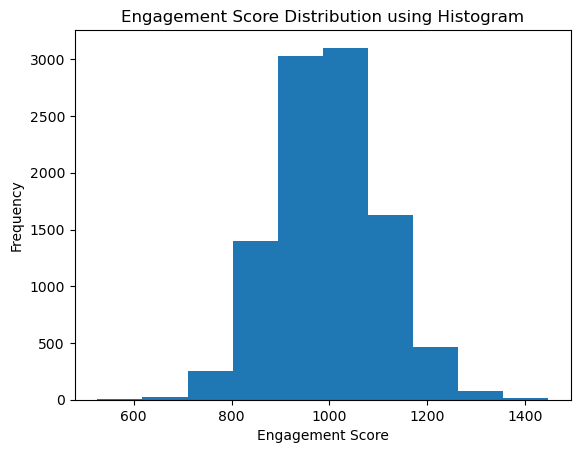

In [11]:
plt.hist(df["engagement_score"])
plt.title("Engagement Score Distribution using Histogram")
plt.xlabel("Engagement Score")
plt.ylabel("Frequency")
plt.show()

In [12]:
df['engagement_score'].describe()

count    10000.000000
mean       996.671475
std        107.029183
min        525.470000
25%        923.180000
50%        994.055000
75%       1066.642500
max       1447.810000
Name: engagement_score, dtype: float64

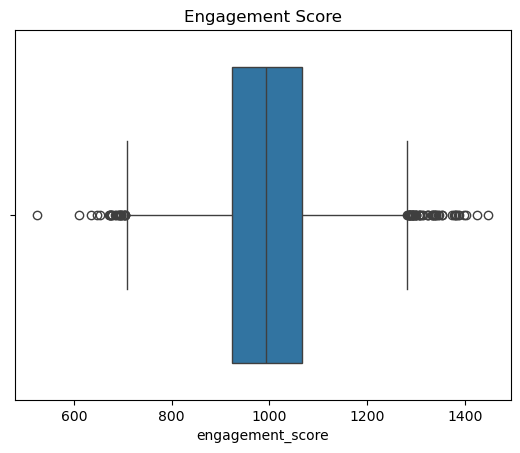

In [13]:
sns.boxplot(x=df['engagement_score'])
plt.title("Engagement Score")
plt.show()

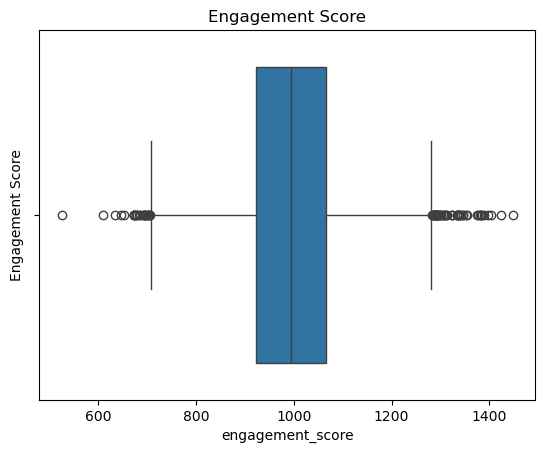

In [17]:
sns.boxplot(x=df['engagement_score'])
plt.title("Engagement Score")
plt.ylabel("Engagement Score")
plt.show()

In [18]:
df.groupby('content_type')['engagement_score'].mean()

content_type
Carousel    1000.612013
Image        971.951577
Reel        1040.843544
Text         963.256707
Video       1014.336697
Name: engagement_score, dtype: float64

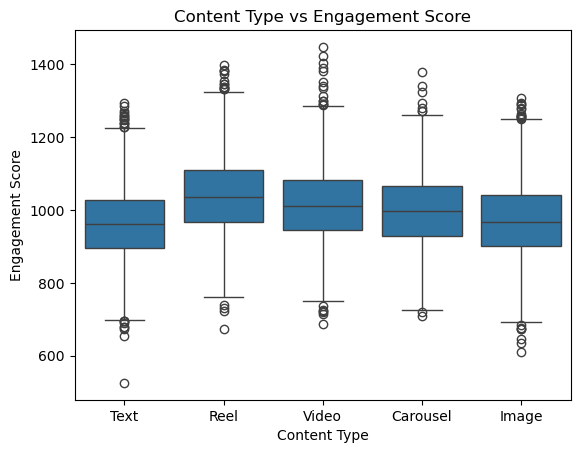

In [19]:
sns.boxplot(x='content_type', y='engagement_score', data=df)
plt.title("Content Type vs Engagement Score")
plt.xlabel("Content Type")
plt.ylabel("Engagement Score")
plt.show()

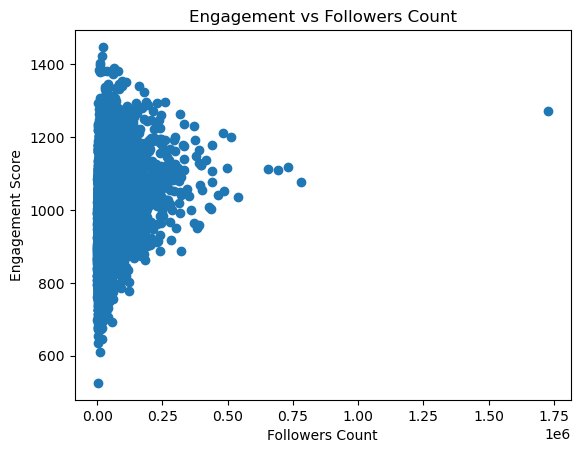

In [4]:
plt.scatter(df['followers_count'], df['engagement_score'])
plt.title("Engagement vs Followers Count")
plt.xlabel("Followers Count")
plt.ylabel("Engagement Score")
plt.show()


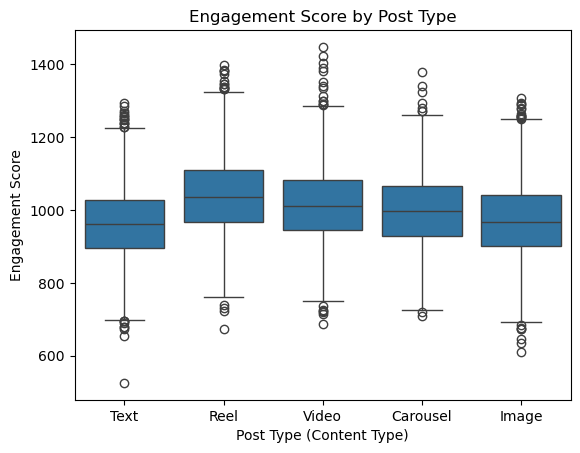

In [5]:
sns.boxplot(x='content_type', y='engagement_score', data=df)
plt.title("Engagement Score by Post Type")
plt.xlabel("Post Type (Content Type)")
plt.ylabel("Engagement Score")
plt.show()

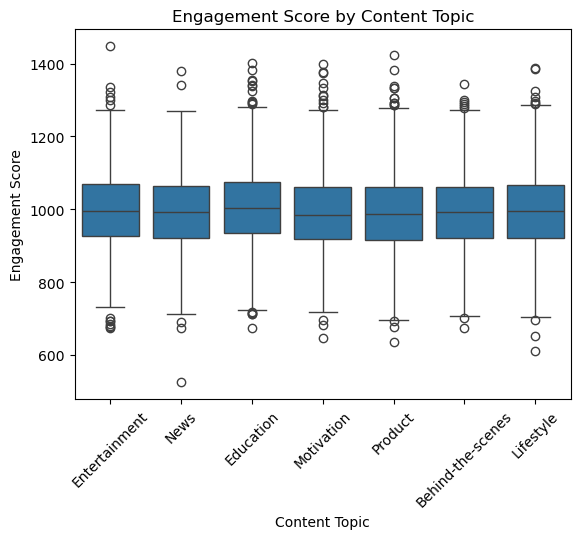

In [6]:
sns.boxplot(x='content_topic', y='engagement_score',data=df)
plt.title("Engagement Score by Content Topic")
plt.xlabel("Content Topic")
plt.ylabel("Engagement Score")
plt.xticks(rotation=45)
plt.show()


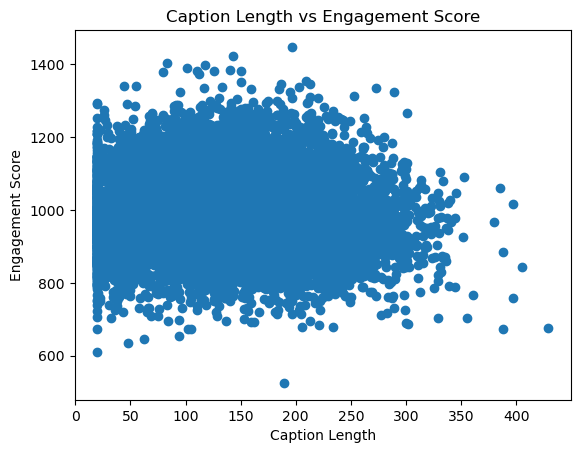

In [7]:
plt.scatter(df['caption_length'], df['engagement_score'])
plt.title("Caption Length vs Engagement Score")
plt.xlabel("Caption Length")
plt.ylabel("Engagement Score")
plt.show()

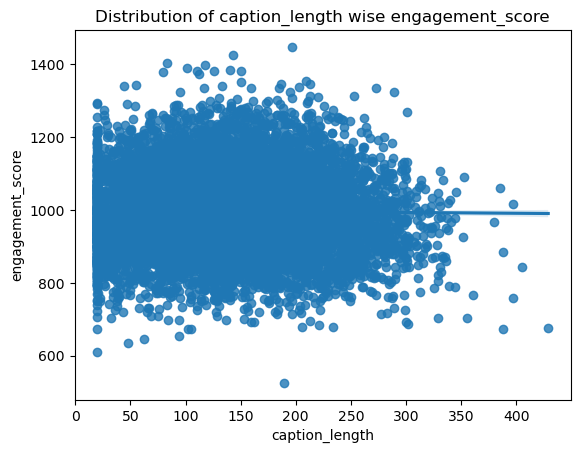

In [8]:
sns.regplot(x="caption_length", y="engagement_score", data=df)
plt.title("Distribution of caption_length wise engagement_score")
plt.xlabel("caption_length")
plt.ylabel("engagement_score")
plt.show()

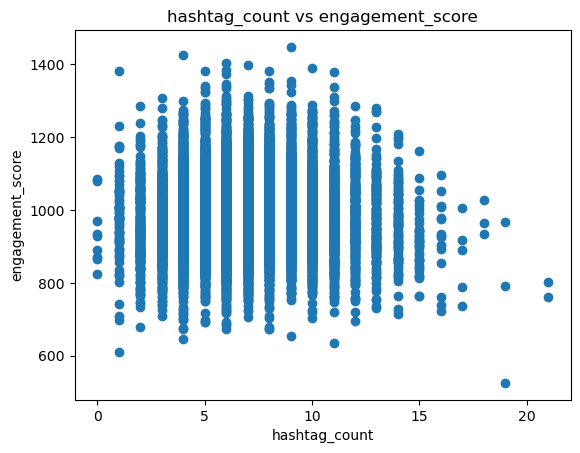

In [9]:
plt.scatter(df['hashtag_count'], df['engagement_score'])
plt.xlabel("hashtag_count")
plt.ylabel("engagement_score")
plt.title("hashtag_count vs engagement_score")
plt.show()

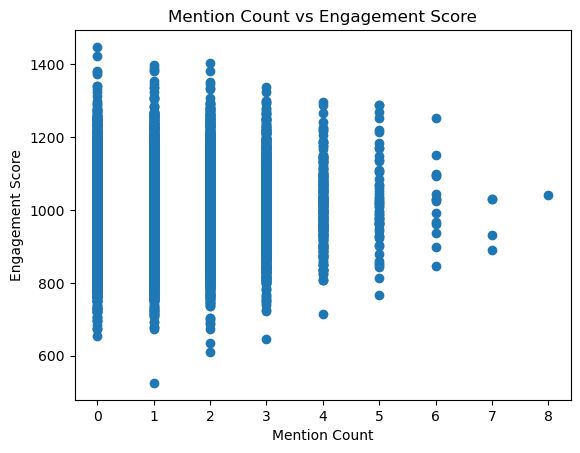

In [10]:
plt.scatter(df['mention_count'], df['engagement_score'])
plt.title("Mention Count vs Engagement Score")
plt.xlabel("Mention Count")
plt.ylabel("Engagement Score")
plt.show()

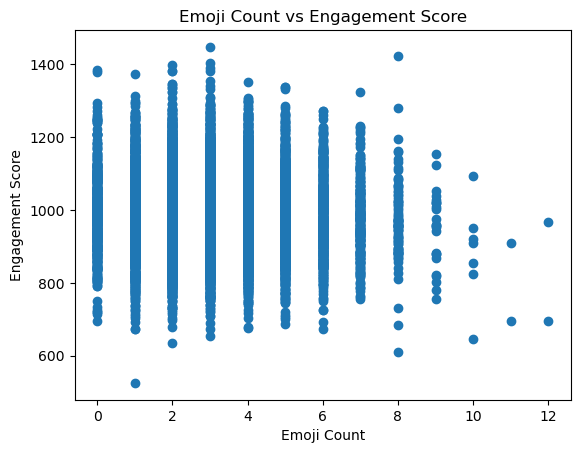

In [11]:
plt.scatter(df['emoji_count'], df['engagement_score'])
plt.title("Emoji Count vs Engagement Score")
plt.xlabel("Emoji Count")
plt.ylabel("Engagement Score")
plt.show()

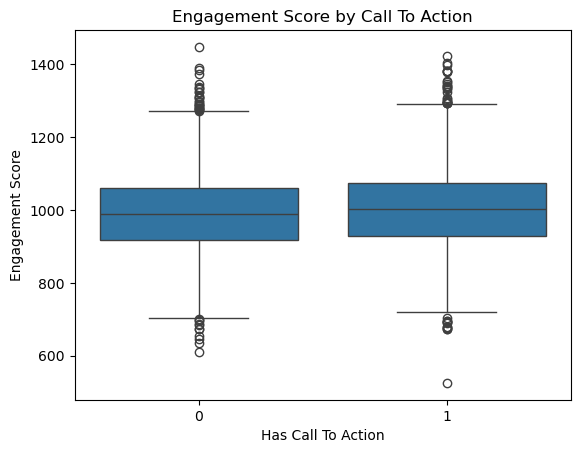

In [12]:
sns.boxplot(x='has_call_to_action', y='engagement_score', data=df)
plt.title("Engagement Score by Call To Action")
plt.xlabel("Has Call To Action")
plt.ylabel("Engagement Score")
plt.show()

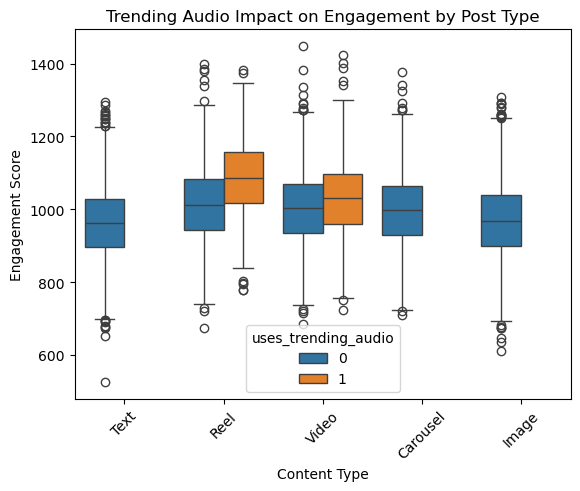

In [13]:
sns.boxplot(x='content_type', y='engagement_score', hue='uses_trending_audio', data=df)
plt.title("Trending Audio Impact on Engagement by Post Type")
plt.xlabel("Content Type")
plt.ylabel("Engagement Score")
plt.xticks(rotation=45)
plt.show()

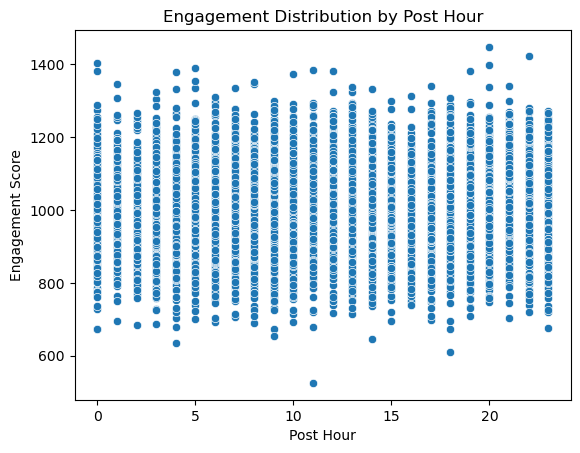

In [14]:
sns.scatterplot(x='post_hour', y='engagement_score', data=df)
plt.title("Engagement Distribution by Post Hour")
plt.xlabel("Post Hour")
plt.ylabel("Engagement Score")
plt.show()

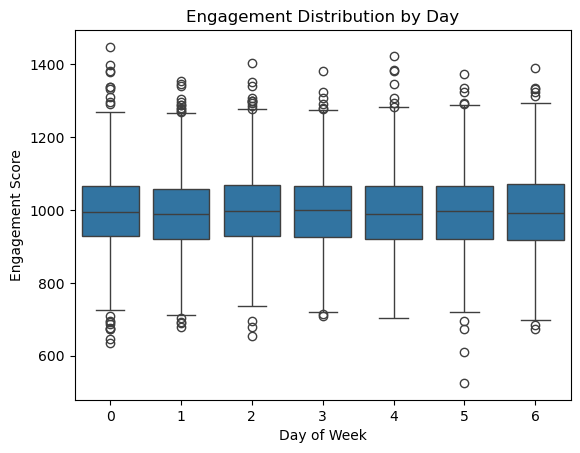

In [15]:
sns.boxplot(x='day_of_week', y='engagement_score', data=df)
plt.title("Engagement Distribution by Day")
plt.xlabel("Day of Week")
plt.ylabel("Engagement Score")
plt.show()

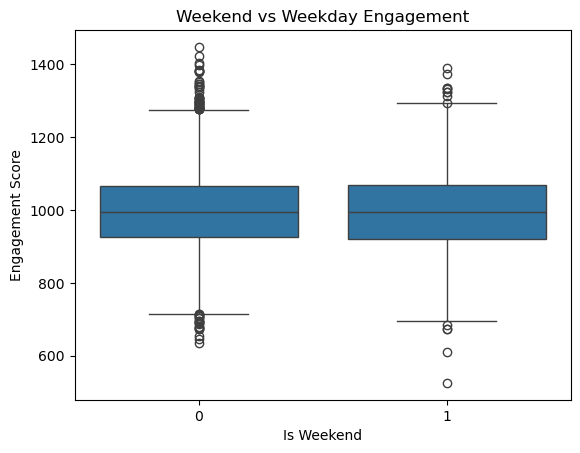

In [16]:
sns.boxplot(x='is_weekend', y='engagement_score', data=df)
plt.title("Weekend vs Weekday Engagement")
plt.xlabel("Is Weekend")
plt.ylabel("Engagement Score")
plt.show()

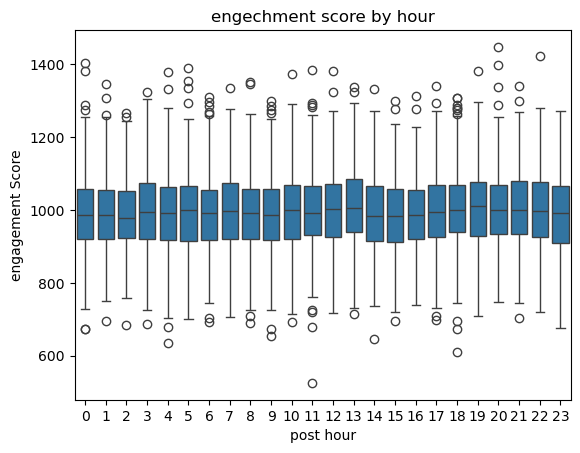

In [19]:
sns.boxplot(x='post_hour', y='engagement_score', data=df)
plt.title("engechment score by hour")
plt.xlabel("post hour")
plt.ylabel("engagement Score")
plt.show()


In [ ]:
def time_period(hour):
    if hour < 6:
        return "Late Night"
    elif hour < 12:
        return "Morning"
    elif hour < 18:
        return "Afternoon"
    else:
        return "Evening"

df['time_period'] = df['post_hour'].apply(time_period)

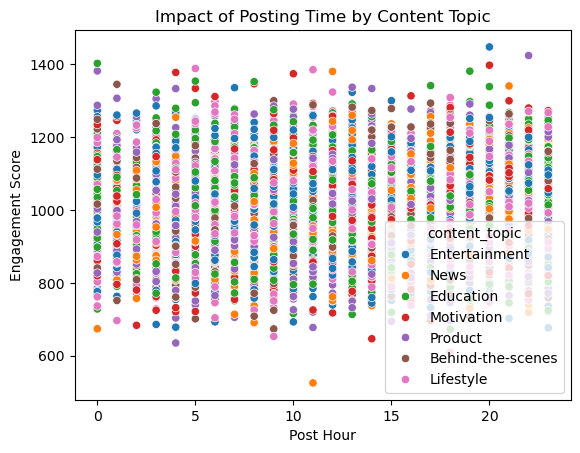

In [7]:
sns.scatterplot(x='post_hour', y='engagement_score', hue='content_topic', data=df)
plt.title("Impact of Posting Time by Content Topic")
plt.xlabel("Post Hour")
plt.ylabel("Engagement Score")
plt.show()

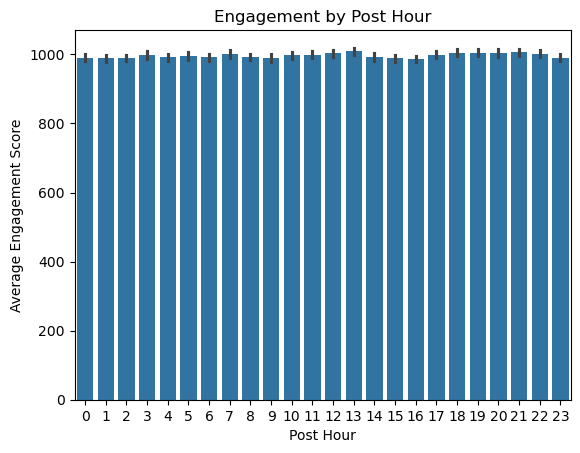

In [8]:
sns.barplot(x='post_hour', y='engagement_score', data=df)
plt.title("Engagement by Post Hour")
plt.xlabel("Post Hour")
plt.ylabel("Average Engagement Score")
plt.show()

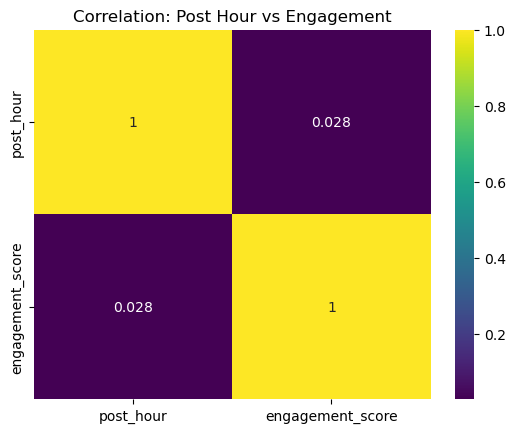

In [10]:
corr = df[['post_hour', 'engagement_score']].corr()

sns.heatmap(corr, annot=True, cmap='viridis')
plt.title("Correlation: Post Hour vs Engagement")
plt.show()


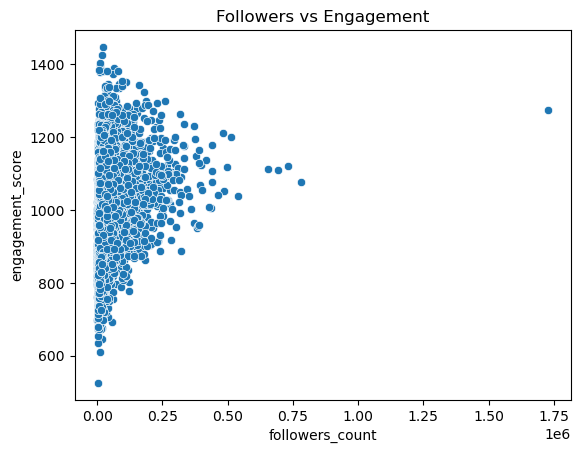

In [11]:
sns.scatterplot(x='followers_count', y='engagement_score', data=df)
plt.title("Followers vs Engagement")
plt.show()

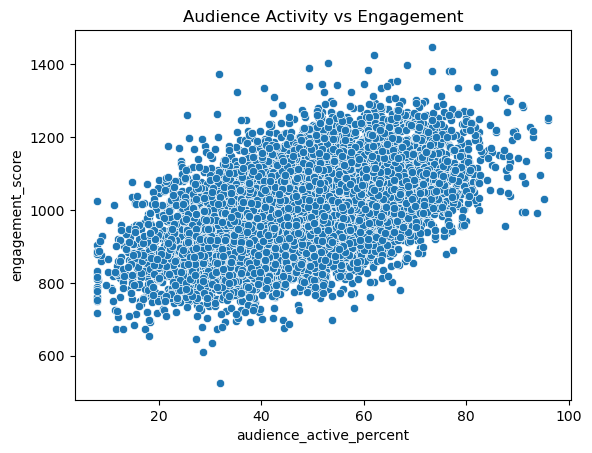

In [12]:
sns.scatterplot(x='audience_active_percent', y='engagement_score', data=df)
plt.title("Audience Activity vs Engagement")
plt.show()

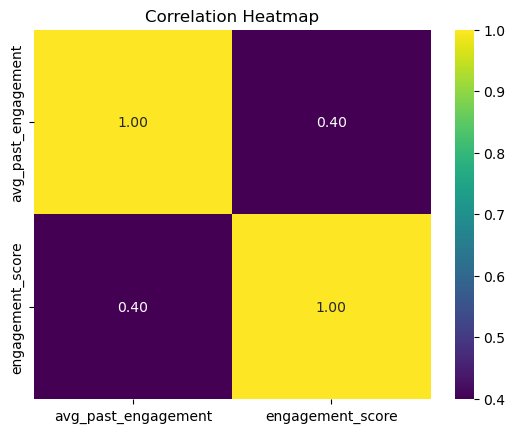

In [14]:
data = ["avg_past_engagement","engagement_score"]
corr_data = df[data]
sns.heatmap(corr_data.corr(), annot=True, cmap='viridis', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

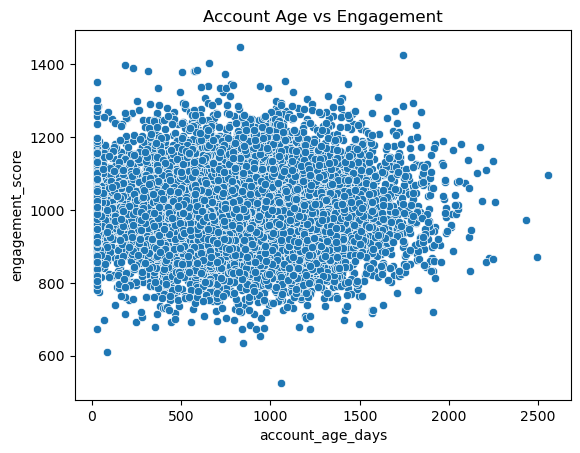

In [15]:
sns.scatterplot(x='account_age_days', y='engagement_score', data=df)
plt.title("Account Age vs Engagement")
plt.show()


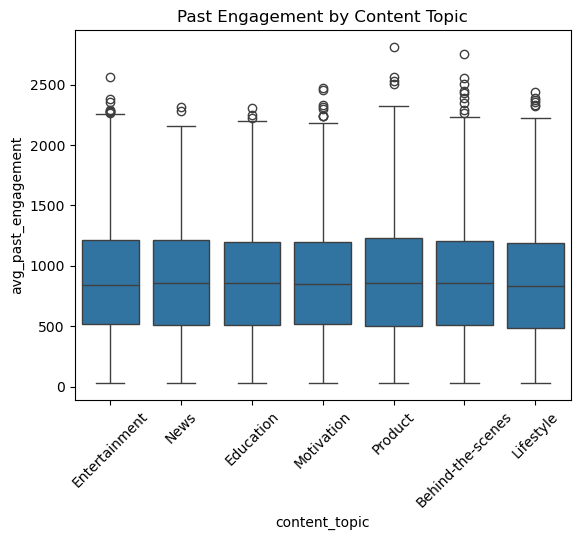

In [16]:
sns.boxplot(x='content_topic', y='avg_past_engagement', data=df)
plt.xticks(rotation=45)
plt.title("Past Engagement by Content Topic")
plt.show()


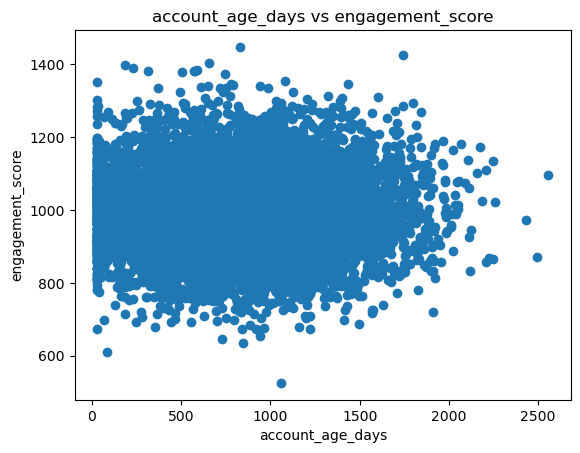

In [17]:
plt.scatter(df['account_age_days'], df['engagement_score'])
plt.xlabel("account_age_days")
plt.ylabel("engagement_score")
plt.title("account_age_days vs engagement_score")
plt.show()


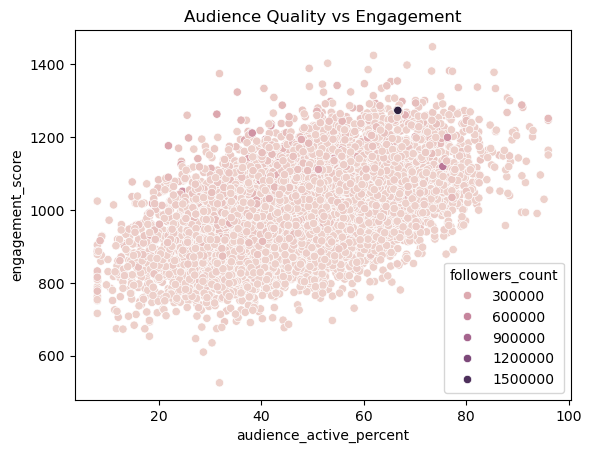

In [18]:
sns.scatterplot(x='audience_active_percent',y='engagement_score',hue='followers_count',data=df)
plt.title("Audience Quality vs Engagement")
plt.xlabel("audience_active_percent")
plt.ylabel("engagement_score")
plt.show()

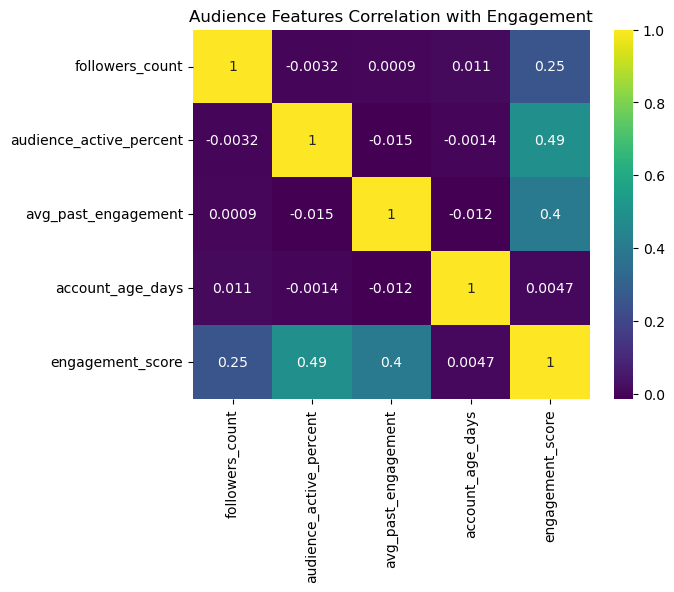

In [19]:
cols = ['followers_count','audience_active_percent','avg_past_engagement','account_age_days','engagement_score']

sns.heatmap(df[cols].corr(), annot=True, cmap='viridis')
plt.title("Audience Features Correlation with Engagement")
plt.show()